In [5]:
import pandas as pd
from matplotlib import pyplot
from pylab import rcParams
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import itertools
from datetime import datetime
import seaborn as sns
import numpy as np
from optbinning import OptimalBinning

In [6]:
df_trave = pd.read_csv('df_traveloka_03032022.csv')
display(df_trave.info())
print('Data Structure Trave Retention Historical')
display(df_trave.shape)
display(df_trave.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206007 entries, 0 to 206006
Data columns (total 15 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   primary_sales_product_type           206007 non-null  object 
 1   is_churn                             206007 non-null  int64  
 2   diff_last_issued_booking_time_hours  206007 non-null  float64
 3   avg_issued_invoice_amount_idr        206007 non-null  float64
 4   pct_succes_trx                       206007 non-null  float64
 5   profile_id                           206007 non-null  int64  
 6   avg_booking_invoice_amount_idr       206007 non-null  float64
 7   count_issued                         206007 non-null  int64  
 8   tenure_hours                         206007 non-null  float64
 9   invoice_per_count_issued             206007 non-null  float64
 10  diff_last_first_booking_time_days    206007 non-null  float64
 11  invoice_per_c

None

Data Structure Trave Retention Historical


(206007, 15)

,primary_sales_product_type,is_churn,diff_last_issued_booking_time_hours,avg_issued_invoice_amount_idr,pct_succes_trx,profile_id,avg_booking_invoice_amount_idr,count_issued,tenure_hours,invoice_per_count_issued,diff_last_first_booking_time_days,invoice_per_count_booking,count_booking,diff_last_first_issued_time_days,cluster
0,HOTEL,0,0.16,1.193237e+06,0.562500,3632279,2.000823e+06,18,28337.007566,66290.932099,1180.702085,62525.709961,32,838.127410,1
1,FLIGHT,0,0.10,1.031982e+06,0.568966,3632279,1.174169e+06,33,38902.531547,31272.171717,1620.934578,20244.291617,58,1616.417011,1
2,TRAIN,0,0.56,2.527762e+05,0.387097,17407638,2.848843e+05,24,15270.677222,10532.340278,636.255093,4594.907648,62,636.269155,1
3,HOTEL,0,0.34,5.875060e+05,0.611111,17407638,7.374472e+05,22,15078.252754,26704.816116,628.246526,20484.644290,36,628.254993,1
4,FLIGHT,0,1075.64,1.443118e+06,0.377358,4618047,1.604698e+06,20,33994.374539,72155.915000,1461.250455,30277.314347,53,1316.119479,1


In [8]:
display(df_trave.cluster.value_counts(dropna=False))
df_retention_trave = df_trave.copy()
df_retention_trave.head()

0    143340
1     62667
Name: cluster, dtype: int64

,primary_sales_product_type,is_churn,diff_last_issued_booking_time_hours,avg_issued_invoice_amount_idr,pct_succes_trx,profile_id,avg_booking_invoice_amount_idr,count_issued,tenure_hours,invoice_per_count_issued,diff_last_first_booking_time_days,invoice_per_count_booking,count_booking,diff_last_first_issued_time_days,cluster
0,HOTEL,0,0.16,1.193237e+06,0.562500,3632279,2.000823e+06,18,28337.007566,66290.932099,1180.702085,62525.709961,32,838.127410,1
1,FLIGHT,0,0.10,1.031982e+06,0.568966,3632279,1.174169e+06,33,38902.531547,31272.171717,1620.934578,20244.291617,58,1616.417011,1
2,TRAIN,0,0.56,2.527762e+05,0.387097,17407638,2.848843e+05,24,15270.677222,10532.340278,636.255093,4594.907648,62,636.269155,1
3,HOTEL,0,0.34,5.875060e+05,0.611111,17407638,7.374472e+05,22,15078.252754,26704.816116,628.246526,20484.644290,36,628.254993,1
4,FLIGHT,0,1075.64,1.443118e+06,0.377358,4618047,1.604698e+06,20,33994.374539,72155.915000,1461.250455,30277.314347,53,1316.119479,1


In [19]:
dfopt = df_retention_trave.copy()
dfopt.head()

,primary_sales_product_type,is_churn,diff_last_issued_booking_time_hours,avg_issued_invoice_amount_idr,pct_succes_trx,profile_id,avg_booking_invoice_amount_idr,count_issued,tenure_hours,invoice_per_count_issued,diff_last_first_booking_time_days,invoice_per_count_booking,count_booking,diff_last_first_issued_time_days,cluster
0,HOTEL,0,0.16,1.193237e+06,0.562500,3632279,2.000823e+06,18,28337.007566,66290.932099,1180.702085,62525.709961,32,838.127410,1
1,FLIGHT,0,0.10,1.031982e+06,0.568966,3632279,1.174169e+06,33,38902.531547,31272.171717,1620.934578,20244.291617,58,1616.417011,1
2,TRAIN,0,0.56,2.527762e+05,0.387097,17407638,2.848843e+05,24,15270.677222,10532.340278,636.255093,4594.907648,62,636.269155,1
3,HOTEL,0,0.34,5.875060e+05,0.611111,17407638,7.374472e+05,22,15078.252754,26704.816116,628.246526,20484.644290,36,628.254993,1
4,FLIGHT,0,1075.64,1.443118e+06,0.377358,4618047,1.604698e+06,20,33994.374539,72155.915000,1461.250455,30277.314347,53,1316.119479,1


#### 1. count_issued

Optimal Splits :  [ 1.5  2.5  3.5  5.5  8.5 17.5]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.50)",74485,0.361565,34266,40219,0.539961,-0.577797,0.124672,0.015371
1,"[1.50, 2.50)",33629,0.163242,18135,15494,0.460733,-0.260221,0.011293,0.001408
2,"[2.50, 3.50)",19184,0.093123,11654,7530,0.392515,0.019143,0.000034,0.000004
3,"[3.50, 5.50)",22321,0.108351,14834,7487,0.335424,0.266142,0.007427,0.000926
4,"[5.50, 8.50)",17603,0.085449,12841,4762,0.270522,0.574364,0.025946,0.003199
5,"[8.50, 17.50)",20728,0.100618,16508,4220,0.203589,0.946399,0.076964,0.009277
6,"[17.50, inf)",18057,0.087652,15966,2091,0.115800,1.615208,0.166342,0.018792
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,206007,1.000000,124204,81803,0.397088,,0.412679,0.048976


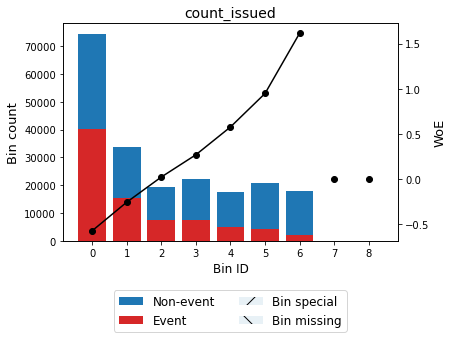

None

In [20]:
#count_issued
optb = OptimalBinning(name='count_issued', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['count_issued'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 2. invoice_per_count_booking

Optimal Splits :  [ 11922.5859375   24750.97753906  37861.24609375  49089.9765625
  72219.68359375  88573.75390625 108706.9609375  134813.875
 165405.9375     210600.4765625  307076.5        390731.703125
 512066.796875  ]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 11922.59)",11112,0.053940,9759,1353,0.121760,1.558254,0.096663,1.099186e-02
1,"[11922.59, 24750.98)",16331,0.079274,12961,3370,0.206356,0.929421,0.058698,7.084124e-03
2,"[24750.98, 37861.25)",14508,0.070425,10593,3915,0.269851,0.577767,0.021625,2.666117e-03
3,"[37861.25, 49089.98)",10658,0.051736,7427,3231,0.303153,0.414719,0.008419,1.044844e-03
4,"[49089.98, 72219.68)",17919,0.086982,11855,6064,0.338412,0.252769,0.005389,6.717935e-04
5,"[72219.68, 88573.75)",10336,0.050173,6358,3978,0.384868,0.051323,0.000131,1.642775e-05
6,"[88573.75, 108706.96)",10644,0.051668,6429,4215,0.395998,0.004558,0.000001,1.341122e-07
7,"[108706.96, 134813.88)",11488,0.055765,6693,4795,0.417392,-0.084123,0.000398,4.971546e-05
8,"[134813.88, 165405.94)",10784,0.052348,6135,4649,0.431102,-0.140254,0.001043,1.302784e-04
9,"[165405.94, 210600.48)",12598,0.061153,6756,5842,0.463724,-0.272254,0.004634,5.774744e-04


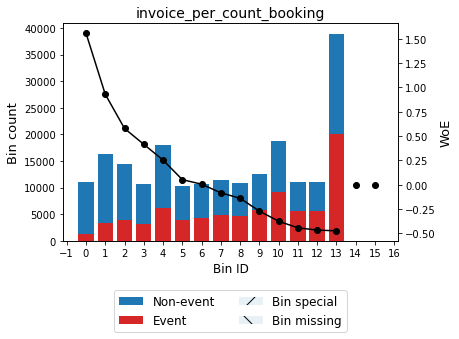

None

In [21]:
#invoice_per_count_booking
optb = OptimalBinning(name='invoice_per_count_booking', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['invoice_per_count_booking'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 3. count_booking

Optimal Splits :  [ 1.5  2.5  3.5  4.5  5.5  7.5  9.5 12.5 16.5 27.5 47.5]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.50)",33880,0.164460,15867,18013,0.531671,-0.544464,0.050336,0.006215
1,"[1.50, 2.50)",25446,0.123520,12222,13224,0.519689,-0.496407,0.031400,0.003885
2,"[2.50, 3.50)",19268,0.093531,9934,9334,0.484430,-0.355312,0.012124,0.001508
3,"[3.50, 4.50)",14840,0.072036,7941,6899,0.464892,-0.276949,0.005650,0.000704
4,"[4.50, 5.50)",11798,0.057270,6653,5145,0.436091,-0.160569,0.001498,0.000187
5,"[5.50, 7.50)",17791,0.086361,10431,7360,0.413692,-0.068889,0.000413,0.000052
6,"[7.50, 9.50)",13097,0.063576,8224,4873,0.372070,0.105735,0.000702,0.000088
7,"[9.50, 12.50)",13901,0.067478,9117,4784,0.344148,0.227252,0.003391,0.000423
8,"[12.50, 16.50)",12418,0.060280,8632,3786,0.304880,0.406555,0.009439,0.001172
9,"[16.50, 27.50)",18542,0.090007,13904,4638,0.250135,0.680282,0.037584,0.004609


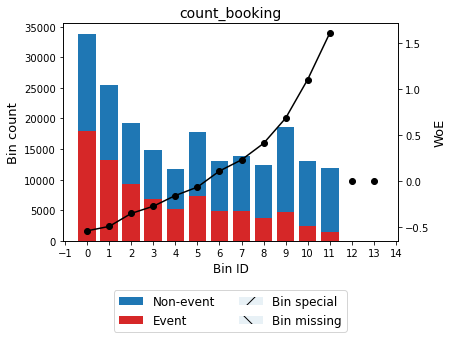

None

In [22]:
#count_booking
optb = OptimalBinning(name='count_booking', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['count_booking'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 4. pct_succes_trx

Optimal Splits :  [0.20050251 0.33395292 0.50113124 0.66705975 0.75040984 0.99456522]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.20)",19391,0.094128,10501,8890,0.458460,-0.251068,0.006058,0.000755
1,"[0.20, 0.33)",31494,0.152878,17843,13651,0.433448,-0.149813,0.003478,0.000434
2,"[0.33, 0.50)",46164,0.224089,27659,18505,0.400853,-0.015701,0.000055,0.000007
3,"[0.50, 0.67)",29789,0.144602,20818,8971,0.301151,0.424209,0.024581,0.003050
4,"[0.67, 0.75)",11846,0.057503,8698,3148,0.265744,0.598714,0.018888,0.002326
5,"[0.75, 0.99)",15565,0.075556,12249,3316,0.213042,0.889074,0.051641,0.006251
6,"[0.99, inf)",51758,0.251244,26436,25322,0.489238,-0.374558,0.036222,0.004501
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,206007,1.000000,124204,81803,0.397088,,0.140923,0.017325


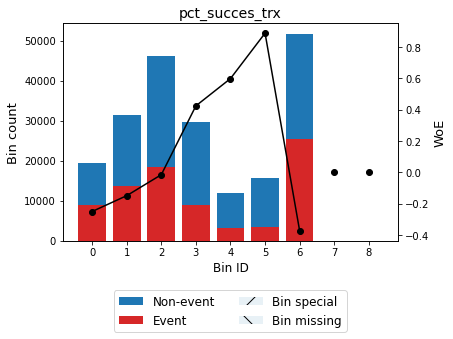

None

In [23]:
#pct_succes_trx
optb = OptimalBinning(name='pct_succes_trx', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['pct_succes_trx'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 5. avg_booking_invoice_amount_idr

Optimal Splits :  [ 210794.75      301288.        367534.671875  433266.046875
  504955.5       587234.4375    672920.75      770886.625
  894425.125     999561.75     1307363.75     1498896.      ]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 210794.75)",16103,0.078167,11196,4907,0.304726,0.407282,0.012282,0.001525
1,"[210794.75, 301288.00)",13617,0.066100,8820,4797,0.352280,0.19142,0.002368,0.000296
2,"[301288.00, 367534.67)",10944,0.053124,6551,4393,0.401407,-0.018006,0.000017,0.000002
3,"[367534.67, 433266.05)",10620,0.051552,6111,4509,0.424576,-0.113596,0.000672,0.000084
4,"[433266.05, 504955.50)",11268,0.054697,6316,4952,0.439475,-0.174317,0.001688,0.000211
5,"[504955.50, 587234.44)",12312,0.059765,6717,5595,0.454435,-0.234843,0.003362,0.000419
6,"[587234.44, 672920.75)",11846,0.057503,6660,5186,0.437785,-0.167455,0.001637,0.000204
7,"[672920.75, 770886.62)",12842,0.062338,7283,5559,0.432876,-0.147487,0.001374,0.000172
8,"[770886.62, 894425.12)",14558,0.070668,8484,6074,0.417228,-0.083447,0.000496,0.000062
9,"[894425.12, 999561.75)",11138,0.054066,6627,4511,0.405010,-0.032978,0.000059,0.000007


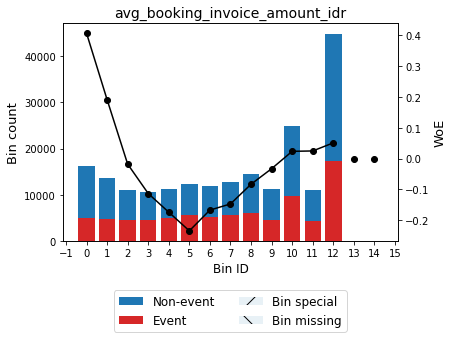

None

In [24]:
#avg_booking_invoice_amount_idr
optb = OptimalBinning(name='avg_booking_invoice_amount_idr', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['avg_booking_invoice_amount_idr'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 6. diff_last_issued_booking_time_hours

Optimal Splits :  [3.49999992e-02 5.49999997e-02 7.49999993e-02 9.50000025e-02
 1.34999998e-01 1.85000002e-01 4.77391504e+03]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.03)",10831,0.052576,8330,2501,0.230911,0.785561,0.028668,0.003494
1,"[0.03, 0.05)",17351,0.084225,12718,4633,0.267016,0.592202,0.027099,0.003339
2,"[0.05, 0.07)",18123,0.087973,12429,5694,0.314186,0.363008,0.011058,0.001375
3,"[0.07, 0.10)",15279,0.074167,10150,5129,0.335690,0.264952,0.005040,0.000628
4,"[0.10, 0.13)",20912,0.101511,13164,7748,0.370505,0.11244,0.001267,0.000158
5,"[0.13, 0.19)",16059,0.077954,9501,6558,0.408369,-0.0469,0.000172,0.000022
6,"[0.19, 4773.92)",97151,0.471591,56025,41126,0.423320,-0.108454,0.005604,0.000700
7,"[4773.92, inf)",10301,0.050003,1887,8414,0.816814,-1.91252,0.167659,0.018253
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


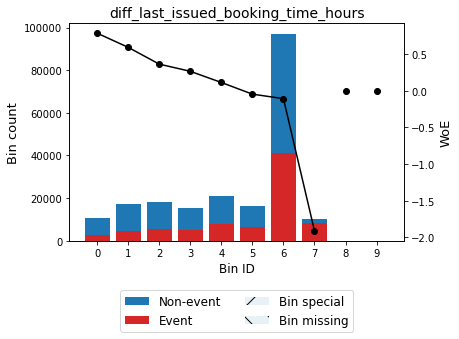

None

In [25]:
#diff_last_issued_booking_time_hours
optb = OptimalBinning(name='diff_last_issued_booking_time_hours', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['diff_last_issued_booking_time_hours'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 7. diff_last_first_issued_time_days

Optimal Splits :  [   1.18756467   14.90961218   62.51024437  157.91420746  238.15359497
  390.07376099  518.48294067 1020.92886353]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.19)",81279,0.394545,37354,43925,0.540422,-0.579655,0.136922,0.016880
1,"[1.19, 14.91)",10315,0.050071,5043,5272,0.511100,-0.46202,0.011017,0.001365
2,"[14.91, 62.51)",12528,0.060813,6330,6198,0.494732,-0.396538,0.009835,0.001221
3,"[62.51, 157.91)",16494,0.080065,9295,7199,0.436462,-0.162077,0.002134,0.000266
4,"[157.91, 238.15)",12039,0.058440,7506,4533,0.376526,0.086707,0.000435,0.000054
5,"[238.15, 390.07)",19038,0.092414,13592,5446,0.286059,0.496989,0.021300,0.002635
6,"[390.07, 518.48)",13066,0.063425,10242,2824,0.216133,0.870731,0.041742,0.005059
7,"[518.48, 1020.93)",28384,0.137782,22907,5477,0.192961,1.013274,0.119036,0.014274
8,"[1020.93, inf)",12864,0.062444,11935,929,0.072217,2.13551,0.180953,0.019111
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


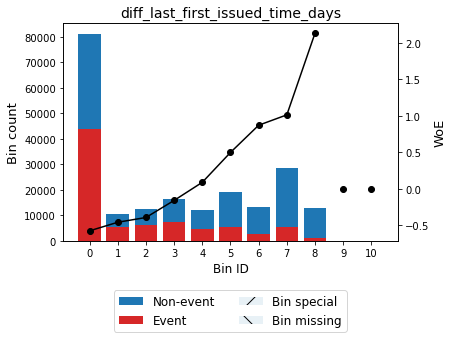

None

In [26]:
#diff_last_first_issued_time_days
optb = OptimalBinning(name='diff_last_first_issued_time_days', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['diff_last_first_issued_time_days'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 8. avg_issued_invoice_amount_idr

Optimal Splits :  [ 188003.4921875  260824.         336967.78125    395568.171875
  469692.5625     546463.84375    705779.8125     849157.40625
  955094.90625   1099840.1875   ]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 188003.49)",14541,0.070585,10014,4527,0.311327,0.376313,0.009515,0.001182
1,"[188003.49, 260824.00)",11008,0.053435,7194,3814,0.346475,0.216957,0.002451,0.000306
2,"[260824.00, 336967.78)",13280,0.064464,8215,5065,0.381401,0.065996,0.000279,0.000035
3,"[336967.78, 395568.17)",10471,0.050828,5997,4474,0.427275,-0.124635,0.000799,0.000100
4,"[395568.17, 469692.56)",12215,0.059294,6854,5361,0.438887,-0.17193,0.001780,0.000222
5,"[469692.56, 546463.84)",12228,0.059357,6691,5537,0.452813,-0.228301,0.003154,0.000393
6,"[546463.84, 705779.81)",23022,0.111753,12926,10096,0.438537,-0.17051,0.003299,0.000412
7,"[705779.81, 849157.41)",17548,0.085182,10212,7336,0.418053,-0.086842,0.000648,0.000081
8,"[849157.41, 955094.91)",11509,0.055867,6886,4623,0.401686,-0.019165,0.000021,0.000003
9,"[955094.91, 1099840.19)",13678,0.066396,8343,5335,0.390042,0.029523,0.000058,0.000007


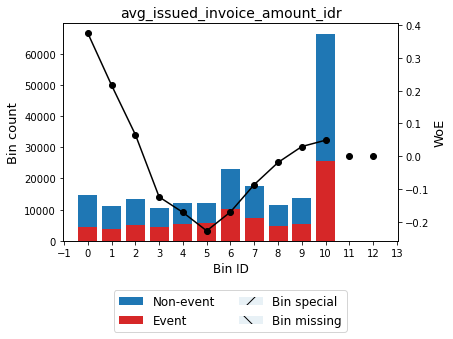

None

In [27]:
#avg_issued_invoice_amount_idr
optb = OptimalBinning(name='avg_issued_invoice_amount_idr', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['avg_issued_invoice_amount_idr'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 9. invoice_per_count_issued

Optimal Splits :  [ 24994.96484375  41653.02148438  68428.05078125 110447.8125
 160333.03125    211070.0859375  260403.25       317137.515625
 390774.796875   524922.75      ]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 24994.96)",11528,0.055959,10410,1118,0.096981,1.813614,0.127219,0.014028
1,"[24994.96, 41653.02)",10309,0.050042,8572,1737,0.168494,1.17873,0.056322,0.006659
2,"[41653.02, 68428.05)",15131,0.073449,11762,3369,0.222655,0.832647,0.044559,0.005414
3,"[68428.05, 110447.81)",20282,0.098453,14396,5886,0.290208,0.476762,0.020955,0.002595
4,"[110447.81, 160333.03)",18669,0.090623,12194,6475,0.346832,0.215384,0.004097,0.000511
5,"[160333.03, 211070.09)",15024,0.072930,9177,5847,0.389177,0.03316,0.000080,0.000010
6,"[211070.09, 260403.25)",12431,0.060343,7100,5331,0.428847,-0.131056,0.001049,0.000131
7,"[260403.25, 317137.52)",11824,0.057396,6486,5338,0.451455,-0.222817,0.002904,0.000362
8,"[317137.52, 390774.80)",12782,0.062046,6497,6285,0.491707,-0.384437,0.009427,0.001171
9,"[390774.80, 524922.75)",16977,0.082410,8264,8713,0.513224,-0.470519,0.018810,0.002330


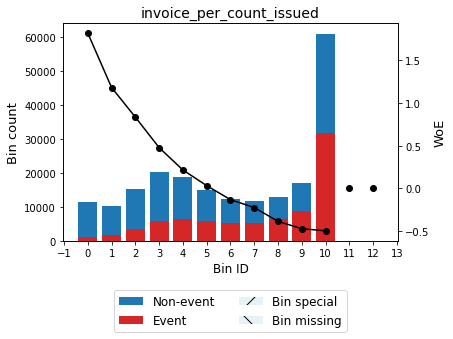

None

In [28]:
#invoice_per_count_issued
optb = OptimalBinning(name='invoice_per_count_issued', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['invoice_per_count_issued'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 10. tenure_hours

Optimal Splits :  [  106.99559402   768.73907471  2204.93713379  3790.53918457
  5737.80737305  9313.74511719 11997.57910156 24650.60839844]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 107.00)",70868,0.344008,31859,39009,0.550446,-0.620084,0.136642,0.016812
1,"[107.00, 768.74)",13946,0.067697,6472,7474,0.535924,-0.561557,0.022046,0.002720
2,"[768.74, 2204.94)",13542,0.065736,6737,6805,0.502511,-0.427654,0.012379,0.001536
3,"[2204.94, 3790.54)",11696,0.056775,6381,5315,0.454429,-0.23482,0.003193,0.000398
4,"[3790.54, 5737.81)",13043,0.063313,7801,5242,0.401901,-0.020063,0.000026,0.000003
5,"[5737.81, 9313.75)",20281,0.098448,14064,6217,0.306543,0.398719,0.014846,0.001844
6,"[9313.75, 11997.58)",12705,0.061673,9755,2950,0.232192,0.778363,0.033063,0.004032
7,"[11997.58, 24650.61)",34002,0.165053,26610,7392,0.217399,0.863277,0.106944,0.012968
8,"[24650.61, inf)",15924,0.077298,14525,1399,0.087855,1.922502,0.191948,0.020870
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


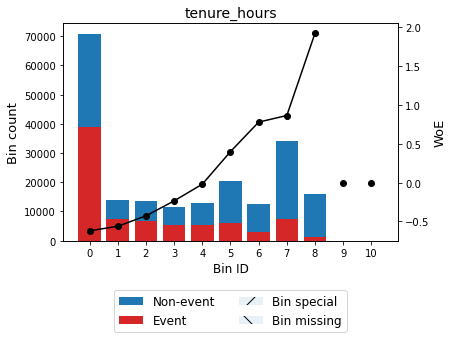

None

In [29]:
#tenure_hours
optb = OptimalBinning(name='tenure_hours', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['tenure_hours'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 11. diff_last_first_booking_time_days

Optimal Splits :  [1.02275133e+00 8.35938358e+00 3.47302113e+01 9.18764381e+01
 1.57934204e+02 2.60040085e+02 3.90173218e+02 4.98582336e+02
 8.62292450e+02 1.09804688e+03]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.02)",54599,0.265035,25593,29006,0.531255,-0.542795,0.080620,0.009956
1,"[1.02, 8.36)",10697,0.051925,5161,5536,0.517528,-0.487753,0.012741,0.001577
2,"[8.36, 34.73)",10744,0.052154,5225,5519,0.513682,-0.472353,0.011997,0.001486
3,"[34.73, 91.88)",13052,0.063357,6778,6274,0.480693,-0.340343,0.007530,0.000937
4,"[91.88, 157.93)",12286,0.059639,6718,5568,0.453199,-0.229857,0.003213,0.000401
5,"[157.93, 260.04)",17145,0.083225,10178,6967,0.406358,-0.038568,0.000124,0.000016
6,"[260.04, 390.17)",18917,0.091827,12378,6539,0.345668,0.220525,0.004349,0.000543
7,"[390.17, 498.58)",13482,0.065444,9599,3883,0.288014,0.487439,0.014534,0.001799
8,"[498.58, 862.29)",29686,0.144102,21840,7846,0.264300,0.606128,0.048446,0.005965
9,"[862.29, 1098.05)",10590,0.051406,7999,2591,0.244665,0.709661,0.023226,0.002844


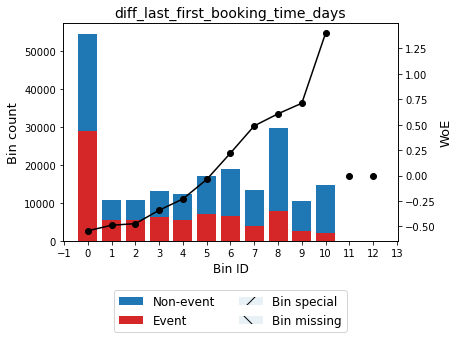

None

In [30]:
#diff_last_first_booking_time_days
optb = OptimalBinning(name='diff_last_first_booking_time_days', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['diff_last_first_booking_time_days'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 12. cluster

Optimal Splits :  [0.5]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",143340,0.695802,73613,69727,0.486445,-0.363377,0.094369,0.011732
1,"[0.50, inf)",62667,0.304198,50591,12076,0.192701,1.014942,0.263579,0.031602
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,206007,1.000000,124204,81803,0.397088,,0.357948,0.043334


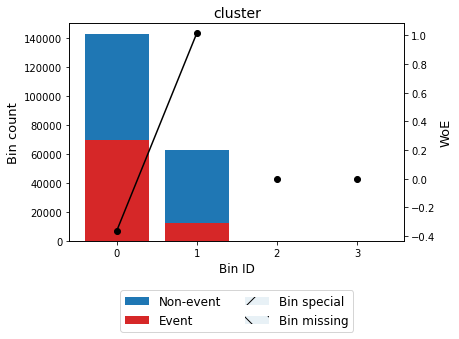

None

In [31]:
#cluster
optb = OptimalBinning(name='cluster', dtype="numerical", solver="cp")
data = dfopt.copy()
x = data['cluster'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

#### 13. primary_sales_product_type

Optimal Splits :  [array(['TRAIN', 'TRIP'], dtype=object), array(['HOTEL'], dtype=object), array(['FLIGHT'], dtype=object)]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[TRAIN, TRIP]",36355,0.176475,26286,10069,0.276963,0.541964,0.047989,0.005926
1,[HOTEL],66028,0.320513,40347,25681,0.388941,0.034154,0.000373,0.000047
2,[FLIGHT],103624,0.503012,57571,46053,0.444424,-0.194385,0.019333,0.002413
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,206007,1.000000,124204,81803,0.397088,,0.067695,0.008386


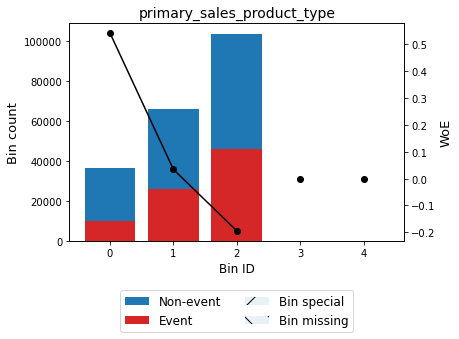

None

In [32]:
#primary_sales_product_type
optb = OptimalBinning(name='primary_sales_product_type', dtype="categorical", solver="cp")
data = dfopt.copy()
x = data['primary_sales_product_type'].values
y = data['is_churn']
optb.fit(x, y)
result = optb.splits
print("Optimal Splits : ", result)
display(optb.binning_table.build())
display(optb.binning_table.plot(metric="woe"))

# Finish